In [19]:
import langchain
langchain.__version__

'1.3.11'

In [29]:
import os
from dotenv import load_dotenv
load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")

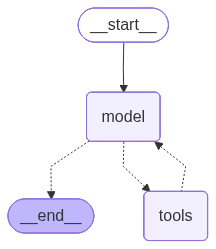

In [24]:
from langchain.agents import create_agent
#tool
def get_weather(city:str)-> str:
    """Get the weather for a city."""
    return f"The weather in {city} is sunny."
    
agent=create_agent(
    #provider:model_name
    model="groq:llama-3.3-70b-versatile",
    #cheezian jo agent use kr sakta hai like current weathe pucha agent se ,blah blah 
    #like internet,calculator .....
    tools=[get_weather],
    #tu hai kya
    system_prompt="You are a helpful assistant."
)
agent

In [25]:
### run the agent
response=agent.invoke({"messages":[{"role":"user","content":"What is the weather like in New York?"}]})

In [ ]:
response["messages"]

In [ ]:
agent.invoke({"messages":"What is the weather in New Yourk"})

### HOW WE INVOKE MODELS

In [ ]:
from langchain.chat_models import init_chat_model
model = init_chat_model("groq:qwen/qwen3-32b")
response = model.invoke("Why do parrots talk?")
response.content


### init_chat_model() 
→ LLM ko on karta hai. Ye sirf model se baat karta hai, tools use nahi kar sakta.
### create_agent()
 → LLM ko employee bana deta hai. Ye soch sakta hai ki tool kab use karna hai, tool chala sakta hai, aur phir final answer de sakta hai.
### Ek line yaad rakh:
Chat Model = Brain 🧠
Agent = Brain + Tools + Decision Making 🤖

In [ ]:
#One more chat way 

In [ ]:
from langchain_groq import ChatGroq
model = ChatGroq(model="qwen/qwen3-32b")
response = model.invoke("Why do parrots talk?")
response.content

### stream() 
model ka answer ek saath nahi, balki chhote-chhote chunks mein bhejta hai, isliye real-time typing effect milta hai.
flush=True output ko turant screen par dikhata hai
"Streaming improves user experience by showing the response as it's generated."

In [ ]:
for chunk in model.stream("Write me a 200 words paragraph on Artificial Intelligence"):
    print(chunk.text, end="|", flush=True)

### batch() 
ek hi time par multiple prompts ko process karta hai, instead of baar-baar invoke() call karne ke.
multiple independent requests ko ek hi API call se efficiently process karta hai.

In [ ]:
model.batch(
    ["Why do parrots have colorful feathers?",
    "How do airplanes fly?",
    "What is quantum computing?"],
    config={
        'max_concurrency': 5,  # controls how many requests can run in parallel at the same time. It improves speed when processing multiple independent inputs.
    }
)

## TOOLS
Tools woh external functions ya APIs hote hain jinko AI agent use karta hai real-world tasks perform karne ke liye, jo LLM khud nahi kar sakta.
Example:
Web Search → Latest information lana.
Calculator → Maths solve karna.
Database → Data fetch karna.
Email API → Email bhejna.
Ek line yaad rakh:
LLM sochta hai kya karna hai, Tool woh kaam karke result laata hai. 🚀

### In short
Tools = External functions/services jo AI agent apna kaam karne ke liye use karta hai.
example weather of delhi abhi kaaa current weather

In [41]:
from langchain.tools import tool   # LangChain ka tool decorator import kiya
@tool                             # Is function ko LangChain Tool bana diya
def get_weather(location: str) -> str:
    """Get the weather at a location"""   # Tool ka description (LLM isi se samajhta hai kab use karna hai)
    return f"It's sunny in {location}"    # Weather ka result return kar raha hai (abhi hardcoded)
# Tool ko model ke saath attach (bind) kar diya
model_with_tools = model.bind_tools([get_weather])

In [ ]:
response = model_with_tools.invoke("What's the weather like in Boston?")
print(response)

### TOOL EXECTION LOOP

In [43]:
# User ka question add kiya
messages = [{"role": "user", "content": "What's the weather in Boston?"}]
# Model ne decide kiya kaunsa tool call karna hai
ai_msg = model_with_tools.invoke(messages)
# Model ka tool call save kiya
messages.append(ai_msg)
# Model ke bataye hue tool ko run karo
for tool_call in ai_msg.tool_calls:
    # Tool execute kiya
    tool_result = get_weather.invoke(tool_call)
    # Tool ka result save kiya
    messages.append(tool_result)
# Tool ka result dekar model se final answer liya
final_response = model_with_tools.invoke(messages)
# Final answer print kiya
print(final_response.text)

The weather in Boston is currently sunny. Let me know if you'd like more details! ☀️


# Messages
Messages are the units of conversation that store the complete chat context between the user and the AI model.

Message matlab conversation ka ek record (chat entry). Har message batata hai kisne bola, kya bola aur uske saath extra information.

Example:
User: Hi
AI: Hello! How can I help?
Ye 2 messages hain.

Each Message contains :

## Role: 
Batata hai message kisne bheja (System, Human, AI, ya Tool).
Example: role = "user"
## Content:
 Message ka actual data hota hai, jaise text, image, audio ya document.
Example: content = "What is LangChain?"
## Metadata:
 Message ke baare me extra information store karta hai, jaise token usage, message ID, timestamp, ya model name.
Example: metadata = {"tokens": 25, "model": "gpt-5.5"}R


# Text Prompt

A Text Prompt is a plain text string used to send a single request to an LLM without maintaining conversation history.

Use text prompts when:

You have a single, standalone request
You don’t need conversation history
You want minimal code complexity

# Message Prompt
Message Prompt is a list of messages that stores the complete conversation history and sends it to the LLM.

Why do we need a Message Prompt?

User: My name is Faheem.
AI: Nice to meet you!
User: What's my name?
Agar LLM ko sirf last question bhejoge:
What's my name?
To AI answer de sakta hai:
I don't know.
Reason: AI ke paas previous conversation (context) nahi hai.
issseliye we need Message Prompt taaki AI ko pichli baatien bhi pata rahe 

Example:

messages = [
    SystemMessage(content="You are a helpful assistant."),

    HumanMessage(content="My name is Faheem."),

    AIMessage(content="Nice to meet you!"),
    
    HumanMessage(content="What's my name?")
]

# Message Types

### 1.System Message

System Message AI ko batata hai kaise behave karna hai, uska role kya hai aur kaunse rules follow karne hain.

A SystemMessage represent an initial set of instructions that primes the model’s behavior. You can use a system message to set the tone, define the model’s role, and establish guidelines for responses.

SystemMessage("You are a Java interview expert.")

### 2.Human Message

Represents the user's input or query. It can contain text, images, audio, or files.

HumanMessage("Explain OOP in Java.")

### 3.AI Message

Represents the model's response. It can include text, tool calls, and metadata.

AIMessage("OOP stands for Object-Oriented Programming.")

### 4.Tool Message

Represents the output returned by a tool, which is sent back to the model to generate the final response.

ToolMessage("Temperature: 34°C")




In [ ]:
from langchain.messages import SystemMessage, HumanMessage,AIMessage

messages=[
    SystemMessage("You are a poetry expert"),
    HumanMessage("Write a poem on artificial intelligence")
    #Yani AI ko pehle instruction diya gaya ki tum poetry expert ho, 
    # fir user ne poem likhne ko bola.
]

response=model.invoke(messages)
response.content

In [ ]:
system_msg = SystemMessage("You are a helpful coding assistant.")

messages = [
    system_msg,
    HumanMessage("How do I create a REST API?")
]
response = model.invoke(messages)
print(response.content)

In [ ]:
## Detailed info to the LLM through System message
from langchain.messages import SystemMessage, HumanMessage

system_msg = SystemMessage("""
You are a senior Python developer with expertise in web frameworks.
Always provide code examples and explain your reasoning.
Be concise but thorough in your explanations.
""")

messages = [
    system_msg,
    HumanMessage("How do I create a REST API?")
]
response = model.invoke(messages)
print(response.content)

In [ ]:
## Message Metadata
human_msg = HumanMessage(
    content="Hello!",
    name="alice",  # Optional: identify different users
    id="msg_123",  # Optional: unique identifier for tracing
)
#metadata se user ko identify krna easy hai , like kis user ne kya message bhja , wo pata rehta hai
response = model.invoke([
  human_msg
])
response

In [ ]:
from langchain.messages import AIMessage, SystemMessage, HumanMessage
# Create an AI message manually (e.g., for conversation history)
ai_msg = AIMessage("I'd be happy to help you with that question!")
# Add to conversation history
messages = [
    SystemMessage("You are a helpful assistant"),
    HumanMessage("Can you help me?"),
    ai_msg,  # Insert as if it came from the model
    HumanMessage("Great! What's 2+2?")
]
response = model.invoke(messages)
print(response.content)

In [51]:
response.usage_metadata

{'input_tokens': 53, 'output_tokens': 218, 'total_tokens': 271}

In [52]:
from langchain.messages import AIMessage
from langchain.messages import ToolMessage
# Normally AI khud tool call generate karta hai, yaha manually bana rahe hain.
ai_message = AIMessage(
    content=[],  # Abhi AI ne final answer nahi diya, isliye content empty hai.
    tool_calls=[{
        "name": "get_weather",  # AI ne decide kiya ki get_weather tool call karna hai.
        "args": {"location": "San Francisco"},  # Tool ko location argument pass kiya.
        "id": "call_123"  # Is tool call ki unique ID, baad me ToolMessage isi ID se link hoga.
    }]
)
# Assume weather tool execute ho gaya aur ye result mila.
weather_result = "Sunny, 72°F"
tool_message = ToolMessage(
    content=weather_result,  # Tool ka actual output.
    tool_call_id="call_123"  # Ye ID AIMessage wali tool call ID se match honi chahiye.
)
# Ab poori conversation prepare kar rahe hain.
messages = [
    HumanMessage("What's the weather in San Francisco?"),  # User ka question.
    ai_message,  # AI ne weather tool call karne ka decision liya.
    tool_message,  # Weather tool ne result return kar diya.
]
response = model.invoke(messages)
# Ab HumanMessage + AIMessage + ToolMessage sab LLM ko bheje jaate hain.
# LLM tool ka result padhkar final natural language answer generate karta hai.

In [53]:
tool_message

ToolMessage(content='Sunny, 72°F', tool_call_id='call_123')

# Structured Output
Structured Output ka matlab hai LLM se response ko predefined format (schema) me lena, instead of normal plain text. This makes the output consistent, easy to parse, and easy to use in code.

Example:

 Normal Output:-
John is 22 years old and works as a software engineer.

Structured Output:-

{
  "name": "John",
  "age": 22,
  "job": "Software Engineer"
}

Structured Output ensures that the LLM returns responses in a predefined schema, making them easy to parse and process programmatically.

# Pydantic

Pydantic is a Python library used to create schemas and validate data. It ensures that the LLM's output follows the correct structure and data types.

In [ ]:
from pydantic import BaseModel, Field
# BaseModel schema banane ke liye use hota hai.
# Field har field ke liye description aur validation dene ke liye use hota hai.
class Movie(BaseModel):
    # Movie naam ka ek schema (blueprint) banaya.
    title: str = Field(description="The title of the movie")
    # title naam ki field hogi aur uska type string hoga.
    # Description LLM ko batata hai ki is field me kya fill karna hai.
    year: int = Field(description="The year the movie was released")
    # year field integer hogi.
    # LLM yaha release year return karega.
    director: str = Field(description="The director of the movie")
    # director field string hogi.
    rating: float = Field(description="The movie's rating out of 10")
    # rating field float hogi (jaise 8.7, 9.2).
model_with_structure = model.with_structured_output(Movie)
# Model ko Movie schema ke saath wrap kiya.
# Ab LLM ko bola gaya ki response hamesha Movie schema follow kare.
model_with_structure
# Ye naya model object return karega jo structured output generate karega.

In [55]:
response = model_with_structure.invoke(
    "Tell me about Interstellar."
)

In [56]:
print(response)

title='Interstellar' year=2014 director='Christopher Nolan' rating=8.6


In [ ]:
from pydantic import BaseModel, Field
# BaseModel -> Schema (blueprint) banane ke liye use hota hai.
# Field -> Har field ke liye description aur validation dene ke liye use hota hai.

class Movie(BaseModel):
    # Movie naam ka schema banaya.
    # LLM ko isi structure me output dena hoga.

    """A movie with details."""
    # Optional class description.
    # LLM ko batata hai ki schema kis purpose ke liye hai.

    title: str = Field(..., description="The title of the movie")
    # title field compulsory (...) hai aur string type ki hogi.
    # Description LLM ko guide karta hai ki yaha movie ka title dena hai.

    year: int = Field(..., description="The year the movie was released")
    # year compulsory hai aur integer hona chahiye.

    director: str = Field(..., description="The director of the movie")
    # director compulsory hai aur string type ka hoga.

    rating: float = Field(..., description="The movie's rating out of 10")
    # rating compulsory hai aur float type ki hogi (e.g. 8.8).

model_with_structure = model.with_structured_output(
    Movie,
    include_raw=True
)
# model ko Movie schema ke saath wrap kiya.
# Ab LLM hamesha Movie schema follow karega.
# include_raw=True ka matlab hai:
# 1. Parsed (structured) output bhi do.
# 2. Original AI response (raw AIMessage) bhi do.
# 3. Agar parsing fail ho to parsing_error bhi return karo.
response = model_with_structure.invoke(
    "Provide details about the movie Inception"
)
# User prompt LLM ko bheja.
# LLM pehle answer generate karega.
# Fir Pydantic us answer ko Movie schema me convert karega.
response

### Nested Structure

In [ ]:

class Actor(BaseModel):
    # Actor ka alag schema banaya.
    name: str
    role: str
class MovieDetails(BaseModel):
    # Main Movie schema banaya.
    title: str
    year: int
    cast: list[Actor]
    # Cast ek list hogi.
    # Lekin list ke andar simple strings nahi,
    # Actor schema ke objects honge.
    # Yehi Nested Structure kehlata hai.
    genres: list[str]
    # Genres ki list (e.g. Sci-Fi, Action).
    budget: float | None = Field(
        None,
        description="Budget in millions USD"
    )
    # Budget optional hai.
    # Agar budget available nahi ho to None bhi ho sakta hai.
model_with_structure = model.with_structured_output(MovieDetails)
# LLM ko bola ki output MovieDetails schema me return karo.
response = model_with_structure.invoke(
    "Provide details about the movie Inception"
)
print(response)

## TypedDict
TypedDict is a lightweight way to define a schema using Python's built-in typing. Ye Pydantic se simpler hai, lekin runtime validation nahi karta.

Pydantic = Schema + Validation

TypedDict = Sirf Schema (No Validation)

In [ ]:
from typing_extensions import TypedDict, Annotated
# TypedDict import kiya dictionary ka schema banane ke liye.
# Annotated field ki extra information (description) dene ke liye use hota hai.
class MovieDict(TypedDict):
    """A movie with details."""
    # Optional description.
    title: Annotated[str, ..., "The title of the movie"]
    # title key hogi aur uski value string hogi.
    year: Annotated[int, ..., "The year the movie was released"]
    # year key hogi aur integer value hogi.
    director: Annotated[str, ..., "The director of the movie"]
    # director key hogi aur string value hogi.
    rating: Annotated[float, ..., "The movie's rating out of 10"]
    # rating key hogi aur float value hogi.
model_withtypedict = model.with_structured_output(MovieDict)
# LLM ko bola ki output MovieDict schema follow kare.
response = model_withtypedict.invoke(
    "Please provide the details of the movie Avengers"
)
# Prompt LLM ko bheja.
response
# Dictionary return hogi.

# DataClass

A DataClass is a Python class mainly used to store data. By adding the @dataclass decorator,

Python automatically generates common methods like __init__(), __repr__(), and __eq__(), reducing boilerplate code.

Normal Class → Constructor (__init__) khud likhna padta hai.

DataClass → Constructor automatically ban jata hai.

In [62]:
#Aise he model create krke we can also do in pydantic and typedict
from dataclasses import dataclass
from langchain.agents import create_agent
@dataclass
class ContactInfo:
    """Contact information for a person."""
    name: str # The name of the person
    email: str # The email address of the person
    phone: str # The phone number of the person
agent = create_agent(
    model,
    response_format=ContactInfo  # Auto-selects ProviderStrategy
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})
result["structured_response"]

ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')